# Evaluate trials:
# TODO Continue rewrite!

In [7]:
import xarray as xr
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmcrameri as cmc  # noqa: F401
import matplotlib.gridspec as gridspec
from unseen_awg.plotting_utils import add_headers, add_label_to_axes
from tqdm.auto import tqdm
from unseen_awg.weather_generator import WeatherGenerator
import yaml
from icecream import ic
from typing import Tuple

In [2]:
import joblib

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]
mpl.rc_file("../../matplotlibrc")

ALPHABET = "abcdefghij"

It's important to note that there is a seasonality in the predictive skill of all methods. Therefore, if one of the datasets samples the days-of-year with a non-uniform distribution, the outcome may be influenced. As a first order correction, we sample the sets of time steps we start forecasts from such that each month is represented roughly equally often. This is necessary because the re-forecast dataset has an non-uniform distribution of days-of-year.

In [4]:
def string_to_linestyle(
    morse_message: str,
    sf: int = 1,
    l_dash: float = 3,
    l_gap_signal: float = 1,
    l_gap_letter: float = 3,
    l_gap_word: float = 7,
    l_end: float = 10,
) -> Tuple:
    """
    Convert a text message to a matplotlib linestyle tuple representing Morse code.

    This function encodes text as Morse code and converts it to a dash pattern
    suitable for matplotlib line plotting, where dashes and dots are represented
    as line segments of different lengths.

    Parameters
    ----------
    message : str
        The morse mesage message to convert to linestyle.
    sf : int, default 1
        Scale factor to multiply all lengths by.
    l_dash : float, default 3
        Length of a dash in Morse code units.
    l_gap_signal : float, default 1
        Gap length between dots/dashes within a letter.
    l_gap_letter : float, default 3
        Gap length between letters.
    l_gap_word : float, default 7
        Gap length between words.
    l_end : float, default 10
        Length of the final gap at the end of the message.

    Returns
    -------
    tuple
        A matplotlib linestyle tuple (offset, dash_pattern) where offset is 0
        and dash_pattern is a tuple of line/gap lengths.

    Raises
    ------
    AssertionError
        If the Morse code doesn't start with a dot or dash.
    ValueError
        If an invalid character is found in the Morse code.

    Warnings
    --------
    UserWarning
        If the resulting dash pattern has more than 32 elements, which may
        not display properly in some matplotlib backends.

    Notes
    -----
    Uses standard Morse code timing: dash = 3 units, dot = 1 unit,
    gap between signals = 1 unit, gap between letters = 3 units,
    gap between words = 7 units.

    Examples
    --------
    >>> linestyle = string_to_linestyle("SOS")
    >>> print(linestyle)
    (0, (1, 1, 1, 1, 1, 3, 3, 1, 3, 1, 3, 3, 1, 1, 1, 1, 1, 10))
    """
    import warnings

    # Validate morse code starts correctly
    assert morse_message[0] in [
        "-",
        ".",
    ], f"Morse code cannot start with character {morse_message[0]}"

    morse_lengths = []

    for c in morse_message:
        if c == ".":
            morse_lengths.extend([sf, l_gap_signal * sf])
        elif c == "-":
            morse_lengths.extend([l_dash * sf, l_gap_signal * sf])
        elif c == " ":  # Space between letters
            morse_lengths[-1] += (l_gap_letter - l_gap_signal) * sf
        elif c == "/":  # Space between words
            morse_lengths[-1] += (l_gap_word - 2 * l_gap_letter) * sf
        else:
            raise ValueError(f"Invalid character in morse code: {c}")

    # Replace final gap with end length
    morse_lengths[-1] = l_end * sf

    # Warn about matplotlib backend limitations
    if len(morse_lengths) > 32:
        warnings.warn(
            f"Some matplotlib backends don't fully display dash_styles with "
            f"more than 32 items (current: {len(morse_lengths)} items).",
            UserWarning,
        )

    return (0, tuple(morse_lengths))


message = (
    ". -- .- .. .-.. / -- . / .. ..-. / -.-- --- ..- / .-. . .- -.. / - .... .. ..."
)

<>:203: SyntaxWarning: invalid escape sequence '\m'
<>:203: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1997896/587357482.py:203: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$Z_\mathrm{500hPa}$ CRPS [dam]")
/tmp/ipykernel_1997896/1296164609.py:92: UserWarning: Some matplotlib backends don't fully display dash_styles with more than 32 items (current: 98 items).
  warnings.warn(


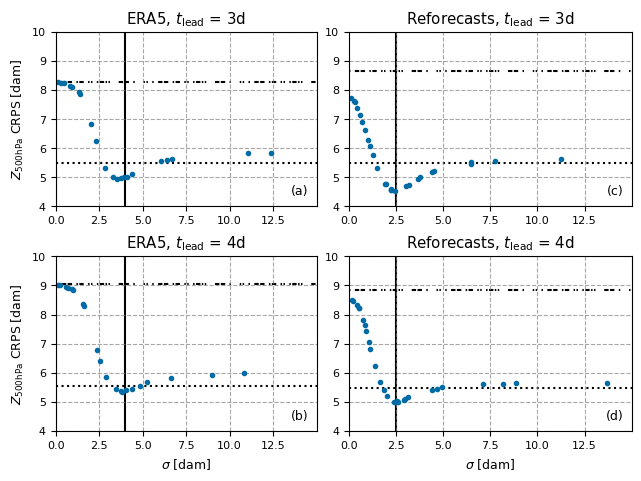

In [21]:
configs = {
    "ERA5": os.path.join(paths["dir_wgs"], "wg_era5_f3d1f2f7_6e629cd9_7560715e_tune"),
    "Reforecasts": os.path.join(
        paths["dir_wgs"], "wg_reforecasts_5e06172f_f40e9460_1e69bda9_tune"
    ),
}


fig = plt.figure()

gs0 = gridspec.GridSpec(1, 2, figure=fig)


for i, (name, path) in enumerate(configs.items()):
    param_configs = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith("optuna_study.pkl"):
                base_file = file.strip("optuna_study.pkl")
                with open(os.path.join(path, base_file + "_params.yaml")) as file:
                    param_configs.append(yaml.safe_load(file))

    seeds = np.unique([cfg["seed"] for cfg in param_configs])
    n_analogs = np.unique([cfg["n_analogs"] for cfg in param_configs])
    lead_time_days = np.unique(
        [cfg["forecast_lead_time_days"] for cfg in param_configs]
    )
    gs_curr = gridspec.GridSpecFromSubplotSpec(
        len(lead_time_days), 1, subplot_spec=gs0[i]
    )

    n_trials = np.unique(
        [cfg["tune_weather_generator.N_optuna_trials"] for cfg in param_configs]
    )
    assert len(n_trials) == 1
    n_trials = n_trials[0]

    results = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    sigma = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    uses_seasonality = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    crps_pers = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days)),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={"seed": seeds, "n_analog": n_analogs, "lead_time": lead_time_days},
    )

    crps_clim = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days)),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={"seed": seeds, "n_analog": n_analogs, "lead_time": lead_time_days},
    )

    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith("optuna_study.pkl"):
                base_file = file.strip("optuna_study.pkl")
                with open(os.path.join(path, base_file + "_params.yaml")) as f:
                    curr_conf = yaml.safe_load(f)

                seed = curr_conf["seed"]
                n_analog = curr_conf["n_analogs"]
                forecast_lead_time_days = curr_conf["forecast_lead_time_days"]
                pkl_file_path = os.path.join(root, file)
                # do something with the pkl file
                study = joblib.load(pkl_file_path)

                results.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array([trial.value for trial in study.trials])
                sigma.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array([trial.params["sigma"] for trial in study.trials])
                uses_seasonality.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array(
                    [
                        True
                        if trial.params["probability_model_type"]
                        == "NormalProbabilityModelSeasonality"
                        else False
                        for trial in study.trials
                    ]
                )

                crps_pers.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = study.user_attrs["crps_pers"]
                crps_clim.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = study.user_attrs["crps_clim"]
    for m, lt in enumerate(lead_time_days):
        ax = fig.add_subplot(gs_curr[m])
        ax.grid(True)
        for j in range(len(sigma.n_analog)):
            for k in range(len(sigma.seed)):
                ax.scatter(
                    sigma.isel(n_analog=j, seed=k).sel(lead_time=lt),
                    results.isel(n_analog=j, seed=k).sel(lead_time=lt),
                    color=f"C{j}",
                    marker=".",
                    zorder=2,
                )

                ax.axhline(
                    crps_pers.isel(n_analog=j, seed=k).sel(lead_time=lt),
                    label=f"Persistence, NAnalog={sigma.n_analog[j].data}",
                    color="k",
                    linestyle=string_to_linestyle(message, sf=0.7, l_gap_word=7),
                    zorder=1,
                )
                ax.axhline(
                    crps_clim.isel(n_analog=j, seed=k).sel(lead_time=lt),
                    label=f"Climatology, NAnalog={sigma.n_analog[j].data}",
                    color="k",
                    linestyle="dotted",
                    zorder=1,
                )
                ax.set_title(name + r", $t_\mathrm{lead}$ = " + f"{lt}d")

        add_label_to_axes(
            ax,
            f"({ALPHABET[m + len(configs) * i]})",
            va="bottom",
            ha="right",
            ax_xpos=0.97,
            ax_ypos=0.05,
        )

        ax.set_xlim(0, 15)
        ax.set_ylim(4, 10)
        ax.set_xticks(np.arange(0, 15, 2.5))

        # plt.yscale("log")
        # plt.legend()
        if m == len(lead_time_days) - 1:
            ax.set_xlabel(r"$\sigma$ [dam]")
        if i == 0:
            ax.set_ylabel("$Z_\mathrm{500hPa}$ CRPS [dam]")
        # ax.set_xticks(np.arange(0, 10.5, 1))
        # ax.minorticks_on()
        # ax.majorticks_on()
        ax.grid(which="both", color="gray")

        if name == "ERA5":
            ax.axvline(4.0, color="k", zorder=1)
        elif name == "Reforecasts":
            ax.axvline(2.5, color="k", zorder=1)
        else:
            raise ValueError(f"Invalid name: {name}")

plt.savefig(os.path.join(paths["dir_images"], "tuning.pdf"), dpi=300)

In [15]:
(len(seeds), len(n_analogs), len(lead_time_days), n_trials.max())

(1, 1, 2, 25)

the lower values for small sigmas is a consequence of the fact that typical simulated trajectories in this case don't resemble persistence forecasts. Instead, we do have transitions in these - improving predictive skill. The difference in climatology is probably (partly) cause by the too small number of n_analog.